# Part 1: STL Decomposition
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — Separate the Signal from the Cycle from the Noise

Yesterday Sarah saw the data has TREND + ANNUAL SEASONALITY + WEEKLY SEASONALITY + NOISE — all overlapping. Today she separates them with STL decomposition.

**Why decompose?** Because each component has different shape, scale, and predictability. By separating them we (a) understand what's driving the series, (b) can forecast each piece with the right tool, and (c) can spot anomalies in the residual that we couldn't see in the raw data.

> Tomorrow (NB 03) Sarah builds baseline forecasts and learns the right way to cross-validate time-series models with `TimeSeriesSplit`.

**By the end of this notebook you will be able to:**
- Run STL decomposition on a daily time series
- Read trend / seasonal / residual components
- Recognise when a chosen seasonal period is the wrong one
- Use the ACF to spot which seasonalities are present

In [1]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 4.5)

print("✅ Libraries loaded — STL ready")

✅ Libraries loaded — STL ready


## Step 1 — Load + DatetimeIndex

In [3]:
df = pd.read_csv("data/northstar_daily_revenue.csv", parse_dates=["date"])
df = df.set_index("date")
y = df["revenue_gbp"]   # the target series — one revenue value per day

print(f"Loaded {len(y)} daily revenue observations")
print(f"Index type: {type(y.index).__name__}")
print(f"Frequency: {y.index.inferred_freq}")

Loaded 731 daily revenue observations
Index type: DatetimeIndex
Frequency: D


## Step 2 — STL with period = 7 (weekly seasonality)

STL (Seasonal and Trend decomposition using Loess) splits a time series into three distinct components: trend, seasonality, and residual noise. Think of the trend as your business's long-term direction, seasonality as your predictable variations (like weekly ups and downs), and residual noise as the random, day-to-day fluctuations. STL needs you to specify the SEASONAL PERIOD. Daily data with weekly seasonality → period=7.

(STL can only handle ONE seasonality. Our data has BOTH weekly and annual — we model the weekly one explicitly here. The annual pattern shows up in the trend component.)

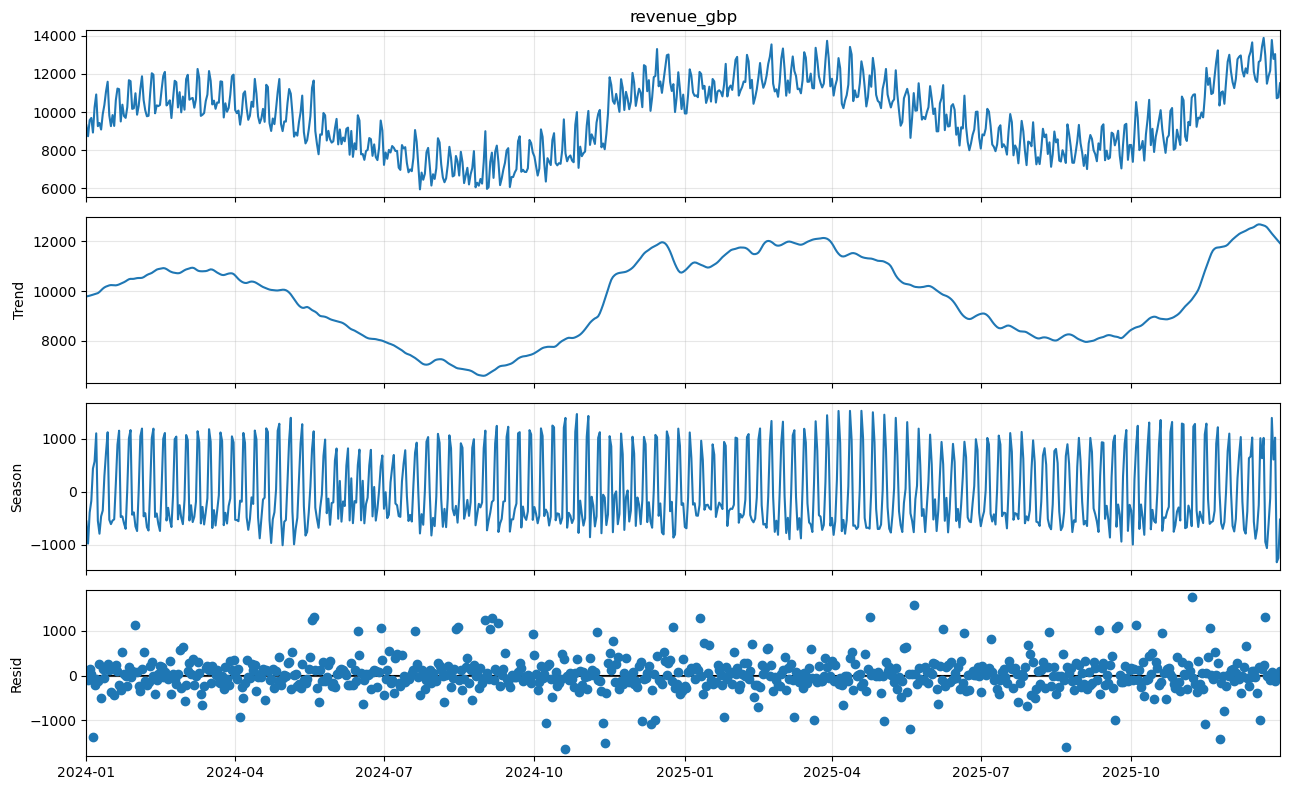

In [4]:
# robust=True ensures that temporary, extreme anomalies do not ruin or distort the smoothed trend line.
stl = STL(y, period=7, robust=True).fit()

# Plot all four panels: observed, trend, seasonal, residual
fig = stl.plot()
fig.set_size_inches(13, 8)
for ax in fig.axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 💡 What you should notice

- **Observed** (top panel): the raw series — what we plotted in NB 01.
- **Trend**: smooth upward curve with the annual cycle visible. Because STL was given period=7, the annual cycle wasn't allocated to "seasonal" and ends up in the trend.
- **Seasonal**: the 7-day weekly cycle, repeating consistently across the whole series.
- **Residual**: what's left — should look like noise. Spikes in the residual are days that surprised the model.

**The decomposition adds up:** `observed = trend + seasonal + residual`. Let's verify.

In [5]:
# Sanity check
reconstructed = stl.trend + stl.seasonal + stl.resid
max_abs_diff = (reconstructed - y).abs().max()
print(f"Max |reconstructed - observed| = {max_abs_diff:.6f}")
print("→ Essentially zero. The components add up exactly to the original series.")

Max |reconstructed - observed| = 0.000000
→ Essentially zero. The components add up exactly to the original series.


## Step 3 — Inspect the seasonal component

Pull out the weekly seasonal pattern. What's the average lift on each day of the week?

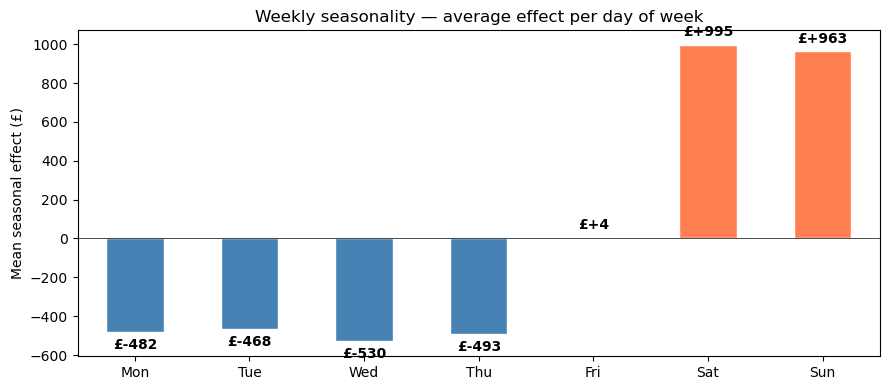

Weekend effect: +£979/day
Weekday effect: £-394/day


In [6]:
# Average STL seasonal effect by day of week.
# Values are deviations from the underlying trend:
# positive = revenue typically above trend, negative = below trend.

seasonal_by_dow = (
    pd.DataFrame({"seasonal": stl.seasonal, "dow": stl.seasonal.index.dayofweek})
    .groupby("dow")["seasonal"].mean()
    .round(0)
)
seasonal_by_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(9, 4))
seasonal_by_dow.plot(kind="bar", ax=ax, color=["steelblue"]*5 + ["coral"]*2, edgecolor="white")
ax.set_ylabel("Mean seasonal effect (£)")
ax.set_xlabel("")
ax.set_title("Weekly seasonality — average effect per day of week")
ax.axhline(0, color="black", linewidth=0.5)
for i, v in enumerate(seasonal_by_dow):
    ax.text(i, v + (30 if v > 0 else -30), f"£{v:+.0f}",
            ha="center", va="bottom" if v > 0 else "top", fontsize=10, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Weekend effect:", f"+£{seasonal_by_dow[['Sat','Sun']].mean():.0f}/day")
print("Weekday effect:", f"£{seasonal_by_dow[['Mon','Tue','Wed','Thu','Fri']].mean():.0f}/day")

## Step 4 — Look at the trend by month

The trend captures slow-moving structure. With period=7, the trend retains BOTH the long-term growth and the annual cycle. Plotting it makes the annual pattern visible cleanly.

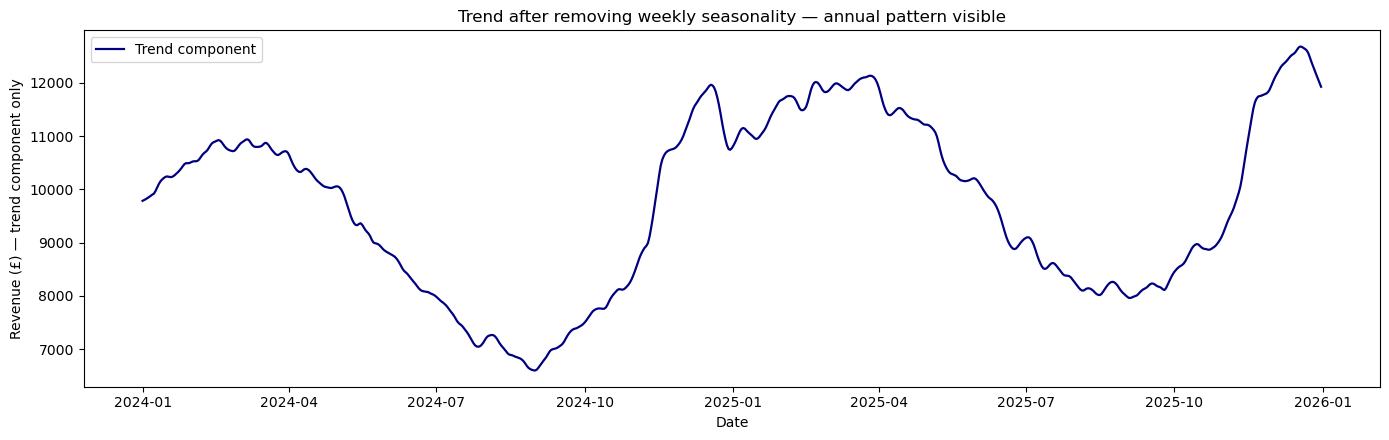

Same-month trend value year-over-year:
  Month 01: 2024 £10,175 → 2025 £11,181  (Δ £+1,006)
  Month 06: 2024 £8,358 → 2025 £9,453  (Δ £+1,095)
  Month 11: 2024 £9,897 → 2025 £10,745  (Δ £+848)


In [9]:
# Monthly mean of the trend — used for the year-over-year comparison below
trend_monthly = stl.trend.resample("ME").mean()

# One clean view: the trend component itself (weekly seasonality already removed),
# so the slow growth + annual cycle show up directly.
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(stl.trend.index, stl.trend.values, color="navy", linewidth=1.6, label="Trend component")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (£) — trend component only")
ax.set_title("Trend after removing weekly seasonality — annual pattern visible")
ax.legend()
plt.tight_layout()
plt.show()

# Year-over-year same-month comparison
print("Same-month trend value year-over-year:")
for month in [1, 6, 11]:
    v2024 = trend_monthly.loc[f"2024-{month:02d}"].mean()
    v2025 = trend_monthly.loc[f"2025-{month:02d}"].mean()
    print(f"  Month {month:02d}: 2024 £{v2024:,.0f} → 2025 £{v2025:,.0f}  (Δ £{v2025-v2024:+,.0f})")

## Step 5 — Inspect the residual

The residual is what remains after removing the trend and seasonal components. Ideally it should resemble random noise with no obvious structure. If you can still see patterns in the residuals, some systematic behaviour remains unexplained — perhaps an additional seasonal effect, holiday impact, promotion, structural change, or other predictable driver. Leaving these patterns in the residuals means the model is failing to capture information that could improve forecasting accuracy, causing predictable revenue peaks and dips to be treated as random fluctuations.

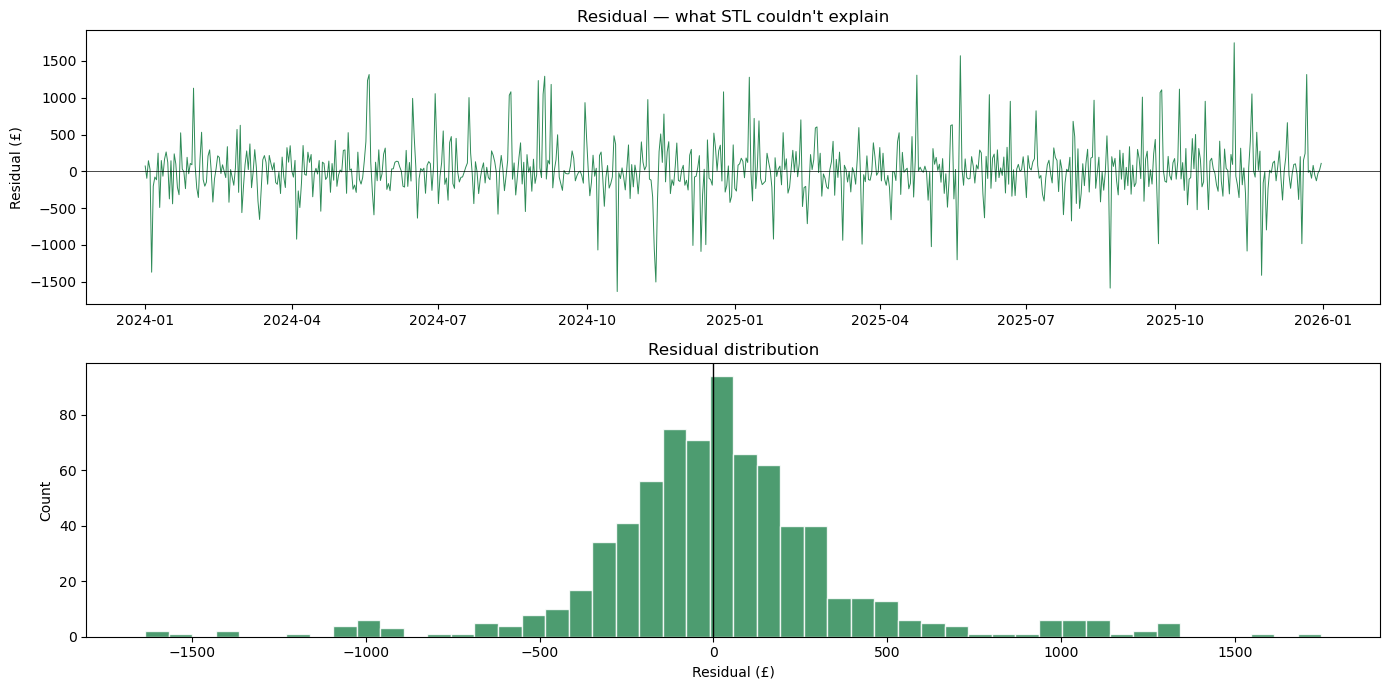

Residual mean: £19.4  (should be near 0)
Residual std:  £382
Residual range: £-1634 to £1747


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Residual over time
axes[0].plot(stl.resid.index, stl.resid.values, linewidth=0.7, color="seagreen")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Residual (£)")
axes[0].set_title("Residual — what STL couldn't explain")

# Residual histogram
axes[1].hist(stl.resid.dropna(), bins=50, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual (£)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

print(f"Residual mean: £{stl.resid.mean():.1f}  (should be near 0)")
print(f"Residual std:  £{stl.resid.std():.0f}")
print(f"Residual range: £{stl.resid.min():.0f} to £{stl.resid.max():.0f}")

### 💡 What you should notice

- **Mean near zero** ✓ — STL extracted the systematic patterns.
- **Roughly normal-looking distribution** ✓ — what's left is genuine random noise.
- **No obvious cyclical pattern in the time plot** ✓ — confirms we captured trend + weekly seasonal.

The residual standard deviation (≈ £380) measures the typical size of the variation that remains after removing the trend and weekly seasonal pattern. It provides a useful benchmark for the amount of unexplained day-to-day fluctuation. However, it is not a hard prediction floor: models can often reduce error further by using additional information (for example, lag features, promotions, holidays, weather, or other external drivers) that STL does not model explicitly.

## ✅ Section Summary

| Step | Output |
|---|---|
| **STL decomposition** | Trend (slow growth + annual pattern) + Seasonal (weekly cycle) + Residual (noise) |
| **Seasonal component** | Weekend lift vs weekday dip, consistent across the series |
| **Trend component** | With period=7, retains long-term growth + the annual cycle |
| **Residual std ≈ £380** | Scale of unmodelled day-to-day noise on normal days (NOT a hard floor) |

**Key insights:**
- **STL with period=7** captures weekly seasonality; the annual pattern goes into the trend.
- **`observed = trend + seasonal + residual`** — the components add back to the original series exactly.
- **Pick the period to match the dominant seasonality** — the wrong period leaks structure into the residual (see Extension 1).
- **The ACF** tells you which lags carry seasonal signal — useful when building lag features later.

---
**Up next → Part 2:** Wednesday — Classical forecasting methods (Naive, Seasonal Naive, ETS), time-series cross-validation, and the MAE / RMSE / MAPE metrics. Build, compare, and pick a winner.
Open `03_classical_forecasting.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — STL with the WRONG period (weekly cycle leaks into the residual)

What if we pick a period that does NOT match the dominant seasonality? Our series is driven by a strong WEEKLY cycle, so the right choice is period=7. Let's instead use period=30 — as if the dominant cycle were roughly monthly — and watch the weekly pattern we failed to remove spill into the residual.

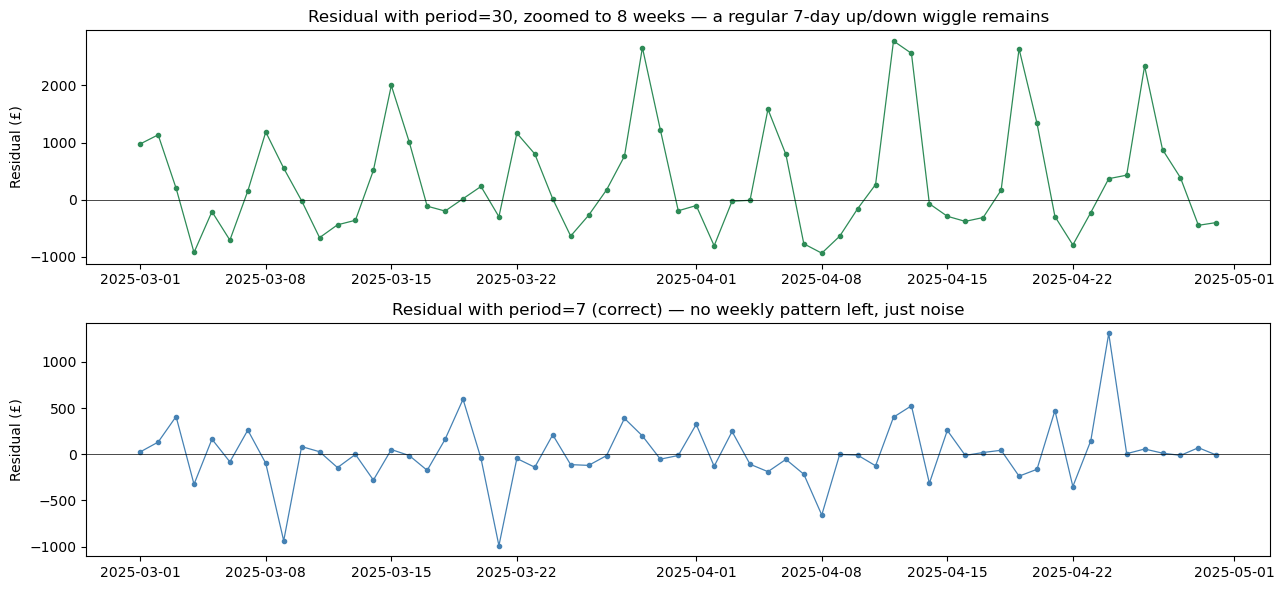

Residual std with period=7  (correct): £382
Residual std with period=30 (wrong):   £772   (much HIGHER)

Residual autocorrelation at lag 7:
  period=7  (correct): -0.179   (≈ 0 → weekly cycle fully removed)
  period=30 (wrong):   +0.692   (strongly positive → weekly cycle STILL there)

The 30-day seasonal component cannot represent a 7-day cycle, so the weekly pattern
is NOT removed — it leaks into the residual as the regular wiggle you see above, and the
residual std nearly doubles. The residual no longer looks like random noise.

Why it matters: that leftover wiggle is predictable structure the model is treating as
random. A forecaster built on this decomposition would systematically miss the weekly
highs and lows — hurting accuracy. Pick the period to match the DOMINANT seasonality,
and use MSTL or lag features when the series has more than one.


In [8]:
stl_wrong = STL(y, period=30, robust=True).fit()

# Zoom into one 8-week window so the leftover weekly wiggle is easy to see
zoom = slice("2025-03-01", "2025-04-30")

fig, axes = plt.subplots(2, 1, figsize=(13, 6))
axes[0].plot(stl_wrong.resid.loc[zoom].index, stl_wrong.resid.loc[zoom].values,
             "o-", color="seagreen", markersize=3, linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Residual with period=30, zoomed to 8 weeks — a regular 7-day up/down wiggle remains")
axes[0].set_ylabel("Residual (£)")

# Same window, correct period=7, for contrast
axes[1].plot(stl.resid.loc[zoom].index, stl.resid.loc[zoom].values,
             "o-", color="steelblue", markersize=3, linewidth=0.9)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Residual with period=7 (correct) — no weekly pattern left, just noise")
axes[1].set_ylabel("Residual (£)")
plt.tight_layout()
plt.show()

print(f"Residual std with period=7  (correct): £{stl.resid.std():.0f}")
print(f"Residual std with period=30 (wrong):   £{stl_wrong.resid.std():.0f}   (much HIGHER)")
print()
print(f"Residual autocorrelation at lag 7:")
print(f"  period=7  (correct): {stl.resid.autocorr(7):+.3f}   (≈ 0 → weekly cycle fully removed)")
print(f"  period=30 (wrong):   {stl_wrong.resid.autocorr(7):+.3f}   (strongly positive → weekly cycle STILL there)")
print()
print("The 30-day seasonal component cannot represent a 7-day cycle, so the weekly pattern")
print("is NOT removed — it leaks into the residual as the regular wiggle you see above, and the")
print("residual std nearly doubles. The residual no longer looks like random noise.")
print()
print("Why it matters: that leftover wiggle is predictable structure the model is treating as")
print("random. A forecaster built on this decomposition would systematically miss the weekly")
print("highs and lows — hurting accuracy. Pick the period to match the DOMINANT seasonality,")
print("and use MSTL or lag features when the series has more than one.")

## Extension 2 — Multi-seasonal decomposition (MSTL)

For series with BOTH weekly AND annual seasonality, statsmodels has MSTL — Multiple Seasonal-Trend decomposition. It runs STL iteratively, peeling off one seasonality at a time.

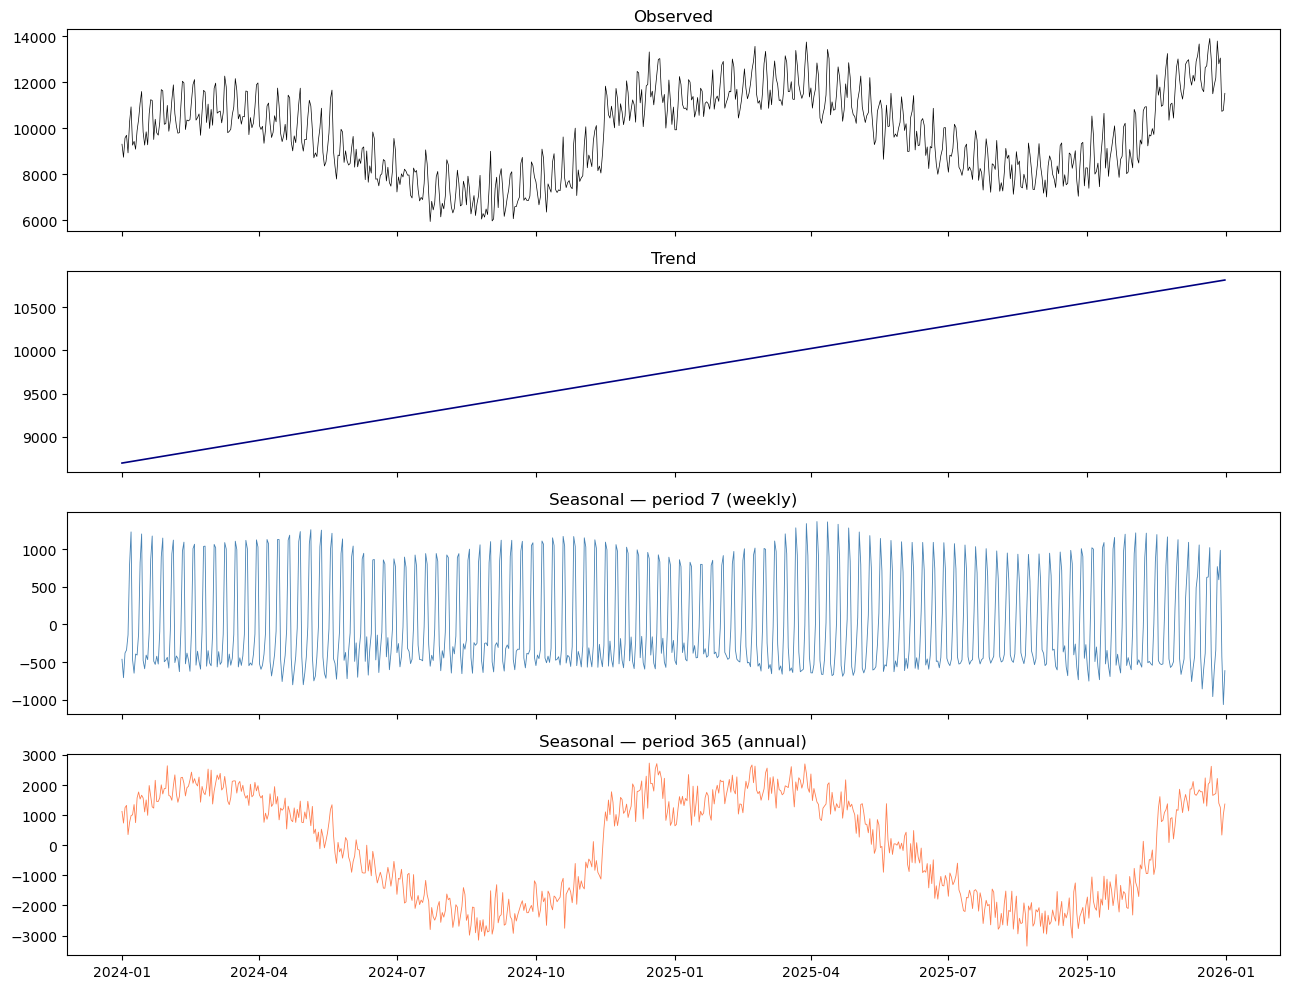

MSTL trend (with both seasonalities removed): smoother than STL trend
Annual seasonal range: £6080
Weekly seasonal range: £2427


In [9]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(y, periods=(7, 365)).fit()

# Plot the components
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
axes[0].plot(y.index, y.values, color="black", linewidth=0.5)
axes[0].set_title("Observed")
axes[1].plot(mstl.trend.index, mstl.trend.values, color="navy", linewidth=1.2)
axes[1].set_title("Trend")
axes[2].plot(mstl.seasonal.index, mstl.seasonal.iloc[:, 0], color="steelblue", linewidth=0.6)
axes[2].set_title("Seasonal — period 7 (weekly)")
axes[3].plot(mstl.seasonal.index, mstl.seasonal.iloc[:, 1], color="coral", linewidth=0.6)
axes[3].set_title("Seasonal — period 365 (annual)")
plt.tight_layout()
plt.show()

print(f"MSTL trend (with both seasonalities removed): smoother than STL trend")
print(f"Annual seasonal range: £{mstl.seasonal.iloc[:, 1].max() - mstl.seasonal.iloc[:, 1].min():.0f}")
print(f"Weekly seasonal range: £{mstl.seasonal.iloc[:, 0].max() - mstl.seasonal.iloc[:, 0].min():.0f}")

## Extension 3 — Read the autocorrelation function (ACF)

ACF (Autocorrelation Function) measures correlation between a time series and its lagged values. It shows how past values relate to current values over different time lags.

ACF plots correlation of the series with its own lagged version. Spikes at lag 7, 14, 21 indicate weekly seasonality, while a spike at lag 365 indicates annual seasonality.

Large spikes show strong dependence on past values, while fast decay toward zero suggests noise-like behaviour. Repeating spike patterns indicate seasonality, and slow decay suggests trend or persistence.

**Interpretation:** ACF helps detect trend, seasonality, and randomness in a series based on how quickly correlations decay.

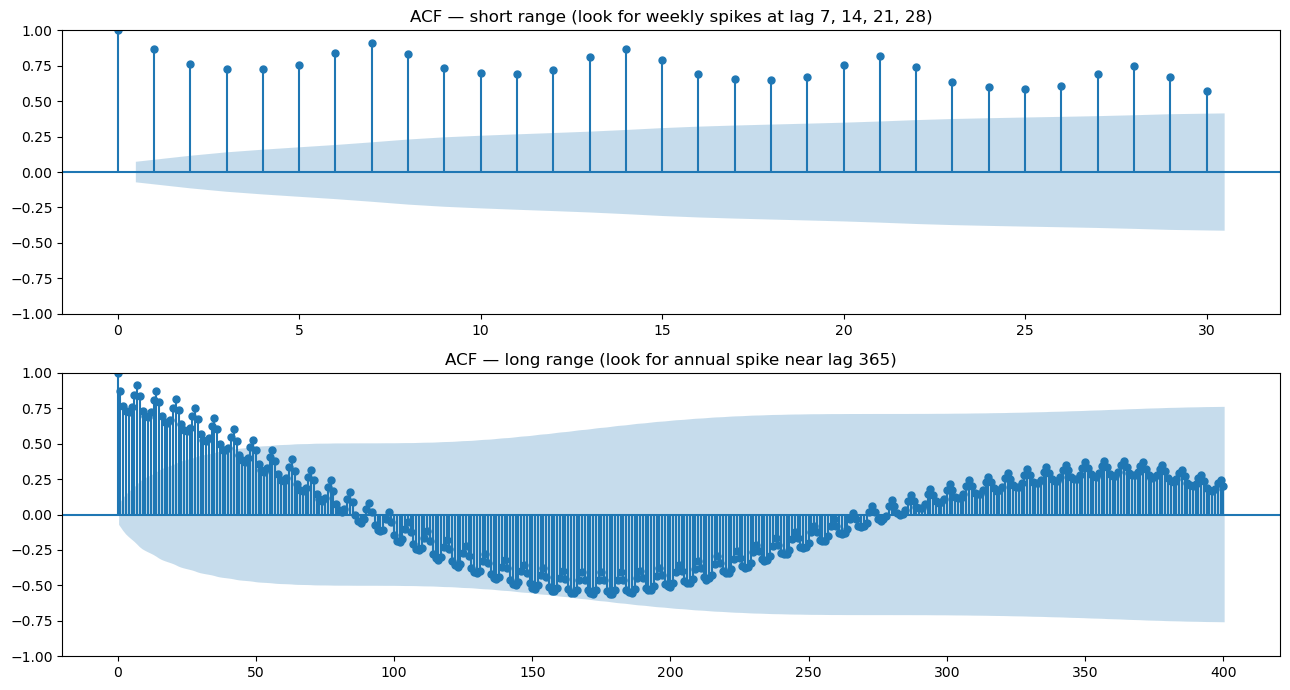

ACF tells you which lag features to add when building the ML forecaster on Thursday.


In [10]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(y, lags=30, ax=axes[0], title="ACF — short range (look for weekly spikes at lag 7, 14, 21, 28)")
plot_acf(y, lags=400, ax=axes[1], title="ACF — long range (look for annual spike near lag 365)")
plt.tight_layout()
plt.show()
print("ACF tells you which lag features to add when building the ML forecaster on Thursday.")